# 臉部驗證

## 使用Face-Recognition套件

## 載入相關套件

In [ ]:
# 載入相關套件
import face_recognition
import numpy as np
from matplotlib import pyplot as plt

/Users/rikenmi/Work/study/python/PyTorch_Book/.venv/lib/python3.12/site-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## 載入並顯示圖檔

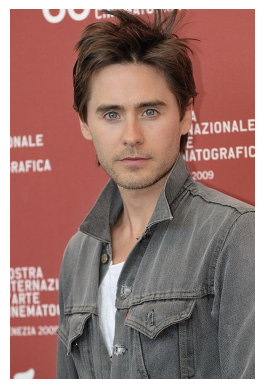

In [2]:
# 載入圖檔
known_image_1 = face_recognition.load_image_file("./images_face/jared_1.jpg")
known_image_2 = face_recognition.load_image_file("./images_face/jared_2.jpg")
known_image_3 = face_recognition.load_image_file("./images_face/jared_3.jpg")
known_image_4 = face_recognition.load_image_file("./images_face/obama.jpg")

# 標記圖檔名稱
names = ["jared_1.jpg", "jared_2.jpg", "jared_3.jpg", "obama.jpg"]

# 顯示圖像
unknown_image = face_recognition.load_image_file("./images_face/jared_4.jpg")
plt.imshow(unknown_image)
plt.axis('off')
plt.show()

## 圖像編碼

In [3]:
# 圖像編碼
known_image_1_encoding = face_recognition.face_encodings(known_image_1)[0]
known_image_2_encoding = face_recognition.face_encodings(known_image_2)[0]
known_image_3_encoding = face_recognition.face_encodings(known_image_3)[0]
known_image_4_encoding = face_recognition.face_encodings(known_image_4)[0]
known_encodings = [known_image_1_encoding, known_image_2_encoding, known_image_3_encoding, known_image_4_encoding]
unknown_encoding = face_recognition.face_encodings(unknown_image)[0]

In [4]:
# 比對
results = face_recognition.compare_faces(known_encodings, unknown_encoding)
print(results)

[np.True_, np.True_, np.True_, np.False_]


## 使用dlib套件

## 載入相關套件

In [ ]:
# 載入相關套件
from typing import List
import cv2
import dlib

## 載入模型

In [7]:
# 載入模型
pose_predictor_5_point = dlib.shape_predictor("./OpenCV/shape_predictor_5_face_landmarks.dat")
face_encoder = dlib.face_recognition_model_v1("./OpenCV/dlib_face_recognition_resnet_model_v1.dat")
detector = dlib.get_frontal_face_detector()

## 定義臉部編碼及比對的函數

In [ ]:
# 找出哪一張臉最相似
def compare_faces_ordered(encodings: List[np.ndarray], face_names: List[str], encoding_to_check: np.ndarray) -> zip:
    distances = list(np.linalg.norm(encodings - encoding_to_check, axis=1))
    return zip(*sorted(zip(distances, face_names)))


# 利用線性代數的法向量比較兩張臉的特徵點
def compare_faces(encodings: List[np.ndarray], encoding_to_check: np.ndarray) -> List[float]:
    return list(np.linalg.norm(encodings - encoding_to_check, axis=1))


# 圖像編碼
def face_encodings(
    face_image: np.ndarray, number_of_times_to_upsample: int = 1, num_jitters: int = 1
) -> List[np.ndarray]:
    # 偵測臉部
    face_locations = detector(face_image, number_of_times_to_upsample)
    # 偵測臉部特徵點
    raw_landmarks = [pose_predictor_5_point(face_image, face_location) for face_location in face_locations]
    # 編碼
    face_image_uint8 = np.asarray(face_image, dtype=np.uint8)
    return [
        np.array(face_encoder.compute_face_descriptor(face_image_uint8, raw_landmark_set, num_jitters))
        for raw_landmark_set in raw_landmarks
    ]

## 載入圖檔並顯示

In [9]:
# 載入圖檔
known_image_1 = cv2.imread("./images_face/jared_1.jpg")
known_image_2 = cv2.imread("./images_face/jared_2.jpg")
known_image_3 = cv2.imread("./images_face/jared_3.jpg")
known_image_4 = cv2.imread("./images_face/obama.jpg")
unknown_image = cv2.imread("./images_face/jared_4.jpg")
names = ["jared_1.jpg", "jared_2.jpg", "jared_3.jpg", "obama.jpg"]

## 圖像編碼

In [10]:
# 圖像編碼
known_image_1_encoding = face_encodings(known_image_1)[0]
known_image_2_encoding = face_encodings(known_image_2)[0]
known_image_3_encoding = face_encodings(known_image_3)[0]
known_image_4_encoding = face_encodings(known_image_4)[0]
known_encodings = [known_image_1_encoding, known_image_2_encoding, known_image_3_encoding, known_image_4_encoding]
unknown_encoding = face_encodings(unknown_image)[0]

In [11]:
# 比對
computed_distances = compare_faces(known_encodings, unknown_encoding)
computed_distances_ordered, ordered_names = compare_faces_ordered(known_encodings, names, unknown_encoding)
print('比較兩張臉的法向量距離：', computed_distances)
print('排序：', computed_distances_ordered)
print('依相似度排序：', ordered_names)

比較兩張臉的法向量距離： [np.float64(0.4637046292165037), np.float64(0.4174236696664251), np.float64(0.42687891989691107), np.float64(0.8422928537975232)]
排序： (np.float64(0.4174236696664251), np.float64(0.42687891989691107), np.float64(0.4637046292165037), np.float64(0.8422928537975232))
依相似度排序： ('jared_2.jpg', 'jared_3.jpg', 'jared_1.jpg', 'obama.jpg')
